<a href="https://colab.research.google.com/github/RughmaMalik/developershub_tasks/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 2: Customer Segmentation Using Unsupervised Learning**

**Objective:** This project focuses on analyzing customer demographics and purchasing behavior to create actionable business insights. By applying unsupervised learning techniques—specifically K-Means clustering and dimensionality reduction (PCA & t-SNE)—we identify distinct customer groups to enable precise, data-backed marketing strategies.

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set(style="whitegrid", palette="muted")

**Load Dataset**

In [2]:
df = pd.read_csv("Mall_Customers.csv")

print("Dataset Loaded Successfully. Shape:", df.shape)

Dataset Loaded Successfully. Shape: (200, 5)


In [3]:
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


**Exploratory Data Analysis (EDA)**

In [16]:
# Statistical Summary
print(df.describe())

       CustomerID       Genre         Age  Annual Income (k$)  \
count  200.000000  200.000000  200.000000          200.000000   
mean   100.500000    0.560000   38.850000           60.560000   
std     57.879185    0.497633   13.969007           26.264721   
min      1.000000    0.000000   18.000000           15.000000   
25%     50.750000    0.000000   28.750000           41.500000   
50%    100.500000    1.000000   36.000000           61.500000   
75%    150.250000    1.000000   49.000000           78.000000   
max    200.000000    1.000000   70.000000          137.000000   

       Spending Score (1-100)     Cluster          PCA1          PCA2  \
count              200.000000  200.000000  2.000000e+02  2.000000e+02   
mean                50.200000    1.755000 -8.881784e-18  1.421085e-16   
std                 25.823522    1.468249  1.155274e+00  1.002134e+00   
min                  1.000000    0.000000 -2.152445e+00 -1.820747e+00   
25%                 34.750000    0.000000 -1.0829

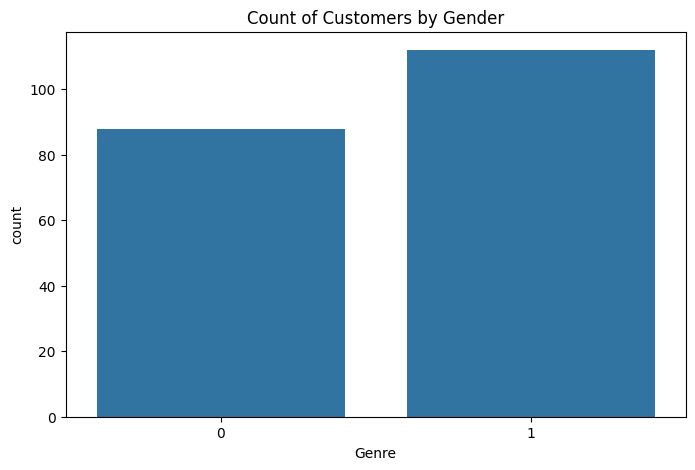

In [24]:
# 1. Distribution of Gender
plt.figure(figsize=(8, 5))
sns.countplot(x='Genre', data=df)
plt.title("Count of Customers by Gender")
plt.show()


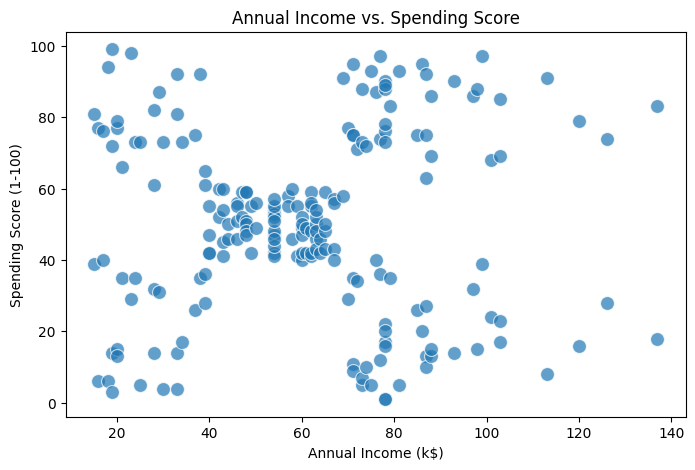

In [23]:
# 3. Income vs. Spending Relationship
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df,
    s=100,
    alpha=0.7
)
plt.title("Annual Income vs. Spending Score")
plt.show()

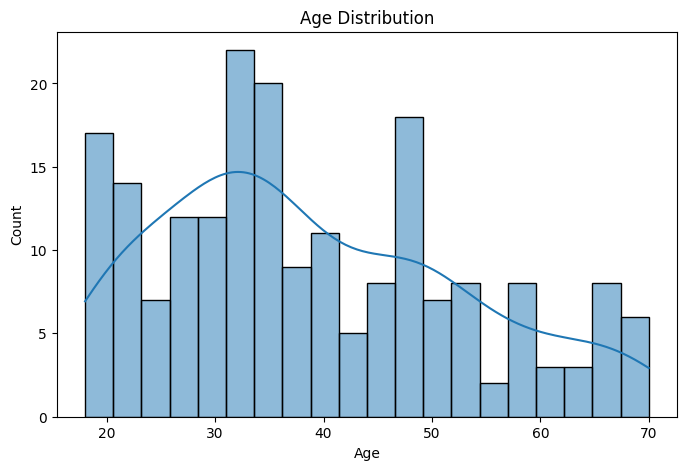

In [25]:
# 4. Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

**Preprocessing**

In [8]:
# Encode Categorical Feature
df['Genre'] = df['Genre'].map({'Male': 0, 'Female': 1})

# Feature Selection
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**K-Means Clustering**

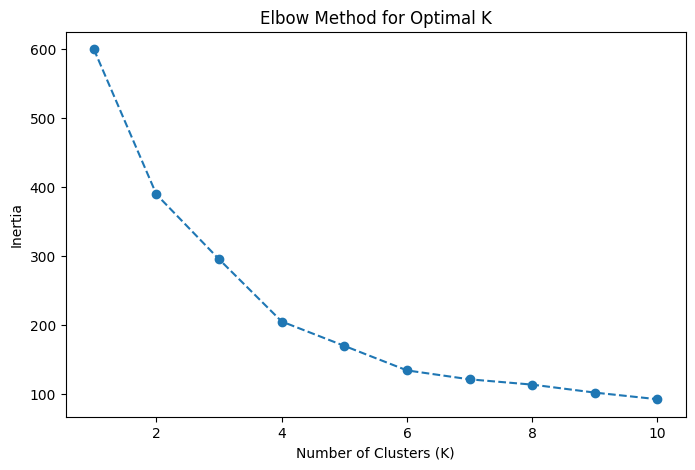

In [28]:
# Finding K using the Elbow Method
inertia_scores = []
cluster_range = range(1, 11)

for k in cluster_range:
    kmeans_model = KMeans(n_clusters=k, random_state=42)
    kmeans_model.fit(X_scaled)
    inertia_scores.append(kmeans_model.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, inertia_scores, marker='o', linestyle='--')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [27]:
# Applying the model with 5 clusters
final_kmeans = KMeans(n_clusters=5, random_state=42)
df['Segment'] = final_kmeans.fit_predict(X_scaled)

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster,PCA1,PCA2,TSNE1,TSNE2,Segment
0,1,0,19,15,39,2,-0.615720,-1.763481,-0.699413,-5.216182,2
1,2,0,21,15,81,2,-1.665793,-1.820747,-6.678774,-4.357728,2
2,3,1,20,16,6,3,0.337862,-1.674799,0.605962,-6.731431,3
3,4,1,23,16,77,2,-1.456573,-1.772430,-6.220541,-4.390894,2
4,5,1,31,17,40,2,-0.038465,-1.662740,0.267134,-5.244290,2


**Cluster Visualization**

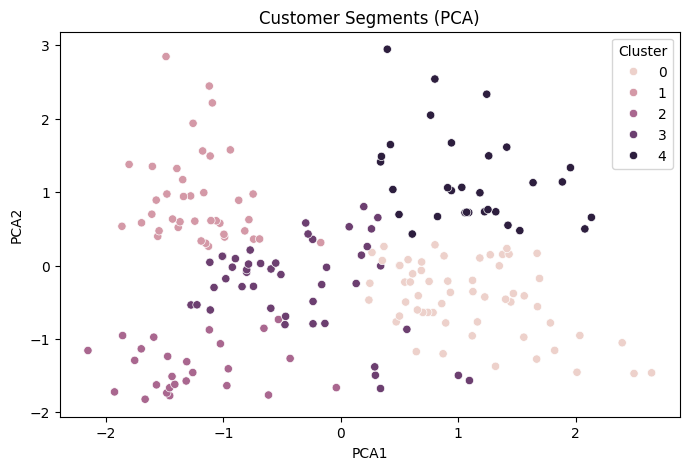

In [30]:
#PCA Visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

df['PCA1'] = pca_components[:, 0]
df['PCA2'] = pca_components[:, 1]
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=df
)
plt.title("Customer Segments (PCA)")
plt.show()


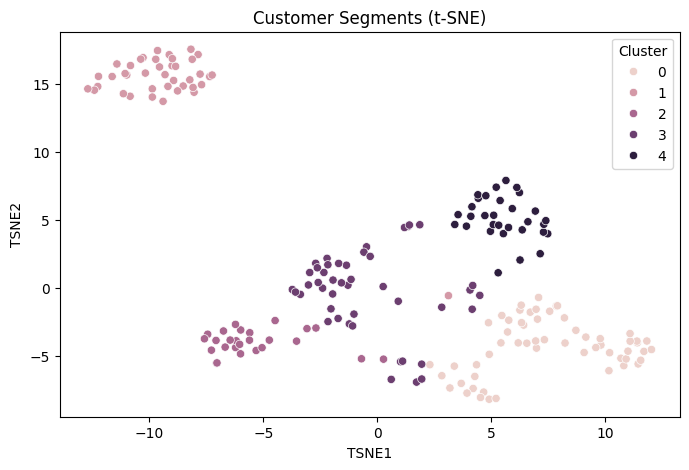

In [32]:
# t-SNE Visualization
tsne = TSNE(n_components=2, random_state=42)
tsne_components = tsne.fit_transform(X_scaled)

df['TSNE1'] = tsne_components[:, 0]
df['TSNE2'] = tsne_components[:, 1]
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    hue='Cluster',
    data=df
)
plt.title("Customer Segments (t-SNE)")
plt.show()

**Cluster Analysis**

In [37]:
cluster_summary = df.groupby('Cluster')[[
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean()

cluster_summary = cluster_summary.rename(columns={
    'Age': 'Average Age',
    'Annual Income (k$)': 'Average Income',
    'Spending Score (1-100)': 'Average Spending Score'
})

cluster_summary

,Average Age,Average Income,Average Spending Score
Cluster,,,
0,55.275862,47.620690,41.706897
1,32.875000,86.100000,81.525000
2,25.769231,26.115385,74.846154
3,26.733333,54.311111,40.911111
4,44.387097,89.774194,18.483871


# Recommended Marketing Strategies

Based on the characteristics of each customer cluster, the following marketing
strategies are recommended:

**Segment 0: Avg Age 55**

*   Profile: Moderate income and spending.
*   Strategy: Prioritize reliability and comfort. Use traditional marketing (email, flyers) and loyalty programs to promote durable goods.

**Segment 1: Avg Age 32**

*   Profile: High income, high spending.
*   Strategy: The VIP target. Focus on luxury items, exclusive memberships, and personalized experiences to capture this premium market.

**Segment 2: Avg Age 25**

*   Profile: Low income, high spending.
*   Strategy: Drive impulse buys via social media trends and flash sales. Offer "Buy Now, Pay Later" options for affordable fashion.

**Segment 3: Avg Age 26**

*   Profile: Moderate income, low spending.
*   Strategy: Focus on price sensitivity. Attract customers with value bundles, discount coupons, and clearance events.

**Segment 4: Avg Age 44**

*   Profile: High income, low spending.
*   Strategy: Hard to convert. Promote high-quality, utility-driven products. Emphasize longevity and investment value over passing trends.